In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tqdm import tqdm


In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Utils

In [37]:
@torch.no_grad()
def run_dynamics_model(agent, initial_obs, action_sequence, n_steps=100):
    """
    Run dynamics model starting from an initial observation.
    
    Args:
        agent: The TDMPC2 agent
        initial_obs: The initial observation (same one used for z_true to ensure consistency)
        n_steps: Number of steps to run
    """
    obs = initial_obs
    if isinstance(obs, np.ndarray):
        obs = torch.from_numpy(obs)
    if obs.ndim == 3:
        obs = obs.unsqueeze(0)

    z = agent.model.encode(obs.to(agent.device), task=None).squeeze(0)
    z_list = [z.cpu().numpy()]

    for t in range(n_steps - 1):
        #NOTE: I think action_sequence[t] is correct, because in e.g. collect_data() first I act and then I collect an observation
        # but we need to double check this.
        z = agent.model.next(z,
                             torch.tensor(action_sequence[t]).to(agent.device),
                             task=None)
        z_list.append(z.cpu().numpy())

    return np.array(z_list)


In [38]:
CKPT_TO_USE = 500_000

## Initialize environment and agent

In [8]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


## Load the data

In [39]:
import pickle

path_off_policy = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_off_policy.pkl"
with open(path_off_policy, 'rb') as f:
    data_off_policy = pickle.load(f)

path_passive = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/data_passive.pkl'
with open(path_passive, 'rb') as f:
    data_passive = pickle.load(f)


In [40]:
data_passive.keys()

dict_keys(['obs_states', 'obs_pixels_dreamer', 'obs_pixels_tdmpc2', 'actions', 'rewards'])

In [41]:
from analysis.utils import reconstruct_cartpole_dmcontrol
from analysis.utils import chunk_data

reconstruct_cartpole_dmcontrol(data_passive['obs_states'][:120], show=True)

100%|██████████| 120/120 [00:02<00:00, 50.06it/s]


In [65]:
data_passive_episodes = {
    key: chunk_data(val, 100) for key, val in data_passive.items()
}
for key in data_passive_episodes:
    print(f"{key}: {len(data_passive_episodes[key])}")

data_offpolicy_episodes = {
    key: chunk_data(val, 100) for key, val in data_off_policy.items()
}
for key in data_offpolicy_episodes:
    print(f"{key}: {len(data_offpolicy_episodes[key])}")


obs_states: 500
obs_pixels_dreamer: 500
obs_pixels_tdmpc2: 500
actions: 500
rewards: 500
obs_states: 250
obs_pixels_dreamer: 250
obs_pixels_tdmpc2: 250
actions: 250
rewards: 250


In [22]:
agent_rgb.eval()
agent_state.eval()
assert not agent_rgb.model._encoder.training
assert not agent_state.model._encoder.training

In [57]:
def evaluate_rollout(agent, obs_true, action_sequence, steps_to_run):

    assert steps_to_run <= len(obs_true)
    if steps_to_run <= len(obs_true):
        obs_true = obs_true[:steps_to_run]
        action_sequence = action_sequence[:steps_to_run]
    obs_true_tensor = torch.from_numpy(obs_true).to(agent.device)
    z_true = agent.model.encode(obs_true_tensor,
                                task=None).detach().cpu().numpy()
    z_predicted = run_dynamics_model(agent, obs_true_tensor[0], action_sequence,
                                     steps_to_run)

    errors_latent = (abs(z_true - z_predicted)).mean(1)
    error_latent_per_dim = [
        (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]

    r2_latent_per_time = [
        r2_score(z_true[t, :], z_predicted[t, :]) for t in range(steps_to_run)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    variance_obs_true_per_dim = np.var(obs_true, axis=0)

    return {
        'obs_true': obs_true,
        'z_true': z_true,
        'z_predicted': z_predicted,
        'errors_latent': errors_latent,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_latent_per_time': r2_latent_per_time,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
        'variance_obs_true_per_dim': variance_obs_true_per_dim,
    }


In [62]:
def evaluate_n_episodes(agent,
                        obs_episodes,
                        acts_episodes,
                        n_episodes,
                        steps_to_run=50):
    results = []
    for i, (obs, acts) in enumerate(
            tqdm(zip(obs_episodes, acts_episodes),
                 total=min(n_episodes, len(obs_episodes)))):
        if i >= n_episodes:
            break
        res = evaluate_rollout(agent, obs, acts, steps_to_run=steps_to_run)
        results.append(res)
    return results


 10%|█         | 1/10 [00:00<00:01,  5.40it/s]

100%|██████████| 10/10 [00:01<00:00,  5.58it/s]


In [78]:
results_state_passive = evaluate_n_episodes(agent_state,
                                            data_passive_episodes['obs_states'],
                                            data_passive_episodes['actions'],
                                            n_episodes=100,
                                            steps_to_run=50)

results_state_offpolicy = evaluate_n_episodes(
    agent_state,
    data_offpolicy_episodes['obs_states'],
    data_offpolicy_episodes['actions'],
    n_episodes=100,
    steps_to_run=50)

100%|██████████| 100/100 [00:17<00:00,  5.57it/s]


In [124]:
# Get indices of episodes where 4th and 5th dims (dx, dth) are between -0.3 and 0.3 ONLY at the initial timestep of the episode
filtered_offpolicy_indices = [
    i for i, ep in enumerate(data_offpolicy_episodes['obs_states'])
    if (-0.3 <= ep[0, 3] <= 0.3) and (-0.3 <= ep[0, 4] <= 0.3)
]
len(filtered_offpolicy_indices)

obs_pixels_passive_filtered = [
    item for idx, item in enumerate(data_passive_episodes['obs_pixels_tdmpc2'])
    if idx in filtered_offpolicy_indices
]

actions_passive_filtered = [
    item for idx, item in enumerate(data_passive_episodes['actions'])
    if idx in filtered_offpolicy_indices
]

results_rgb_passive_low_initial_velocities = evaluate_n_episodes(
    agent_rgb,
    obs_pixels_passive_filtered,
    actions_passive_filtered,
    n_episodes=100,
    steps_to_run=50)

100%|██████████| 53/53 [00:09<00:00,  5.42it/s]


In [128]:
results_rgb_passive = evaluate_n_episodes(
    agent_rgb,
    data_passive_episodes['obs_pixels_tdmpc2'],
    data_passive_episodes['actions'],
    n_episodes=100,
    steps_to_run=50)

results_rgb_offpolicy = evaluate_n_episodes(
    agent_rgb,
    data_offpolicy_episodes['obs_pixels_tdmpc2'],
    data_offpolicy_episodes['actions'],
    n_episodes=100,
    steps_to_run=50)

100%|██████████| 100/100 [00:18<00:00,  5.40it/s]


In [129]:
def get_bootstrap_ci(
    results,
    metric_key='r2_latent_per_time',
    n_bootstrap=1000,
    confidence=0.95,
):
    """
    Plot mean with bootstrap confidence interval.
    """
    data = np.array([r[metric_key] for r in results])
    n_rollouts, n_timesteps = data.shape

    # Bootstrap resampling
    bootstrap_means = np.zeros((n_bootstrap, n_timesteps))
    for i in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_rollouts, size=n_rollouts, replace=True)
        bootstrap_means[i] = np.mean(data[indices], axis=0)

    # Compute percentiles
    alpha = (1 - confidence) / 2
    ci_lower = np.percentile(bootstrap_means, alpha * 100, axis=0)
    ci_upper = np.percentile(bootstrap_means, (1 - alpha) * 100, axis=0)
    mean = np.mean(data, axis=0)

    return mean, ci_lower, ci_upper

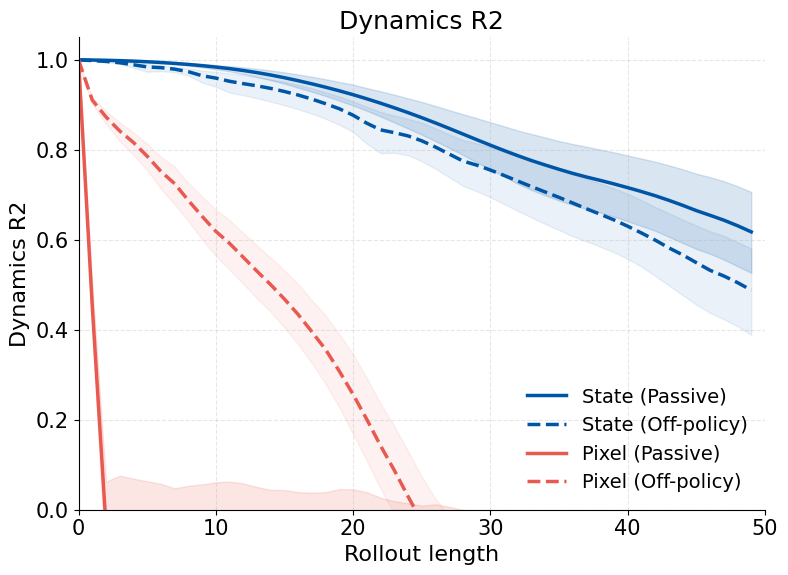

In [131]:
mean_state_passive, ci_lower_state_passive, ci_upper_state_passive = get_bootstrap_ci(
    results_state_passive)
mean_state_offpolicy, ci_lower_state_offpolicy, ci_upper_state_offpolicy = get_bootstrap_ci(
    results_state_offpolicy)
mean_rgb_passive, ci_lower_rgb_passive, ci_upper_rgb_passive = get_bootstrap_ci(
    results_rgb_passive)
mean_rgb_offpolicy, ci_lower_rgb_offpolicy, ci_upper_rgb_offpolicy = get_bootstrap_ci(
    results_rgb_offpolicy)

import matplotlib as mpl

plt.figure(figsize=(8, 6))
# mpl.rcParams.update({
#     "font.size": 15,
#     "axes.labelsize": 16,
#     "axes.titlesize": 18,
#     "legend.fontsize": 14
# })

timesteps = np.arange(len(mean_state_passive))

# Colors: state = blue, rgb pixel = red
state_color = "#0056A6"
rgb_color = "#E85A4F"

# Line styles: passive = solid, offpolicy = dashed
plt.plot(timesteps,
         mean_state_passive,
         color=state_color,
         lw=2.5,
         label="State (Passive)",
         linestyle='-')
# plt.scatter(timesteps,
#             mean_state_passive,
#             color=state_color,
#             s=16,
#             marker='o',
#             alpha=0.75,
#             zorder=3)
plt.fill_between(timesteps,
                 ci_lower_state_passive,
                 ci_upper_state_passive,
                 color=state_color,
                 alpha=0.15)

plt.plot(timesteps,
         mean_state_offpolicy,
         color=state_color,
         lw=2.5,
         label="State (Off-policy)",
         linestyle='--')
# plt.scatter(timesteps,
#             mean_state_offpolicy,
#             color=state_color,
#             s=16,
#             marker='o',
#             alpha=0.55,
#             zorder=3)
plt.fill_between(timesteps,
                 ci_lower_state_offpolicy,
                 ci_upper_state_offpolicy,
                 color=state_color,
                 alpha=0.08)

plt.plot(timesteps,
         mean_rgb_passive,
         color=rgb_color,
         lw=2.5,
         label="Pixel (Passive)",
         linestyle='-')
# plt.scatter(timesteps,
#             mean_rgb_passive,
#             color=rgb_color,
#             s=16,
#             marker='o',
#             alpha=0.75,
#             zorder=3)
plt.fill_between(timesteps,
                 ci_lower_rgb_passive,
                 ci_upper_rgb_passive,
                 color=rgb_color,
                 alpha=0.15)

plt.plot(timesteps,
         mean_rgb_offpolicy,
         color=rgb_color,
         lw=2.5,
         label="Pixel (Off-policy)",
         linestyle='--')
# plt.scatter(timesteps,
#             mean_rgb_offpolicy,
#             color=rgb_color,
#             s=16,
#             marker='o',
#             alpha=0.55,
#             zorder=3)
plt.fill_between(timesteps,
                 ci_lower_rgb_offpolicy,
                 ci_upper_rgb_offpolicy,
                 color=rgb_color,
                 alpha=0.08)

plt.xlabel("Rollout length")
plt.ylabel("Dynamics R2")
plt.title("Dynamics R2")

plt.ylim(0, 1.05)
plt.xlim([timesteps[0], timesteps[-1]])
plt.grid(ls="--", alpha=0.3, zorder=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.xticks(np.arange(timesteps[0], timesteps[-1] + 2,
                     10))  # set xticks every 10 steps
sns.despine()
plt.show()


In [114]:
from analysis.utils import show_video_from_frames

show_video_from_frames(results_rgb_passive[0]['obs_true'][:, 6:9].transpose(
    0, 2, 3, 1),
                       save_to_file="results_rgb_passive.mp4")

Frames shape: (50, 64, 64, 3)
Video file saved at: /hkfs/home/haicore/hgf_hmgu/hgf_gib4562/tdmpc2/results_rgb_passive.mp4


'results_rgb_passive.mp4'